In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, KFold
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

data cleaning


In [3]:
df = pd.read_csv('insuranceWithFeatures.csv')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1338, 15)


,age,sex,bmi,children,smoker,region,charges,smoker-age,Sex-Weight,sexBool,smokerBool,regionSouthWest,regionSouthEast,regionNorthWest,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,19,27.9,1,1,1,0,0,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,0,0.0,0,0,0,1,0,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,0,0.0,0,0,0,1,0,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,0,0.0,0,0,0,0,1,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,0,0.0,0,0,0,0,1,8.260455


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

print('Missing value summary:')
print(missing_df)

if missing.sum() == 0:
    print('\nNo missing values found')
else:
    print('\nMissing values detected')

Missing value summary:
                 Missing Count  Missing (%)
age                          0          0.0
sex                          0          0.0
bmi                          0          0.0
children                     0          0.0
smoker                       0          0.0
region                       0          0.0
charges                      0          0.0
smoker-age                   0          0.0
Sex-Weight                   0          0.0
sexBool                      0          0.0
smokerBool                   0          0.0
regionSouthWest              0          0.0
regionSouthEast              0          0.0
regionNorthWest              0          0.0
log_charges                  0          0.0

No missing values found


In [5]:
print('Data types:')
print(df.dtypes)
print()
print('Summary statistics:')
df.describe(include='all')

Data types:
age                  int64
sex                 object
bmi                float64
children             int64
smoker              object
region              object
charges            float64
smoker-age           int64
Sex-Weight         float64
sexBool              int64
smokerBool           int64
regionSouthWest      int64
regionSouthEast      int64
regionNorthWest      int64
log_charges        float64
dtype: object

Summary statistics:


,age,sex,bmi,children,smoker,region,charges,smoker-age,Sex-Weight,sexBool,smokerBool,regionSouthWest,regionSouthEast,regionNorthWest,log_charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265,7.887145,15.029948,0.494768,0.204783,0.242900,0.272048,0.242900,9.098828
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237,16.772800,15.777241,0.500160,0.403694,0.428995,0.445181,0.428995,0.919379
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.023647
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.464064
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.146658
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515,0.000000,29.925000,1.000000,0.000000,0.000000,1.000000,0.000000,9.719618


In [6]:
df_clean = df.copy()

# Binary encoding for sex and smoker
df_clean['sex']    = df_clean['sex'].map({'male': 0, 'female': 1})
df_clean['smoker'] = df_clean['smoker'].map({'yes': 1, 'no': 0})

# encoding for region
df_clean = pd.get_dummies(df_clean, columns=['region'], drop_first=True)

print('Columns after encoding:')
print(df_clean.columns.tolist())
df_clean.head()

Columns after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'smoker-age', 'Sex-Weight', 'sexBool', 'smokerBool', 'regionSouthWest', 'regionSouthEast', 'regionNorthWest', 'log_charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,smoker-age,Sex-Weight,sexBool,smokerBool,regionSouthWest,regionSouthEast,regionNorthWest,log_charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,19,27.9,1,1,1,0,0,9.734236,False,False,True
1,18,0,33.770,1,0,1725.55230,0,0.0,0,0,0,1,0,7.453882,False,True,False
2,28,0,33.000,3,0,4449.46200,0,0.0,0,0,0,1,0,8.400763,False,True,False
3,33,0,22.705,0,0,21984.47061,0,0.0,0,0,0,0,1,9.998137,True,False,False
4,32,0,28.880,0,0,3866.85520,0,0.0,0,0,0,0,1,8.260455,True,False,False


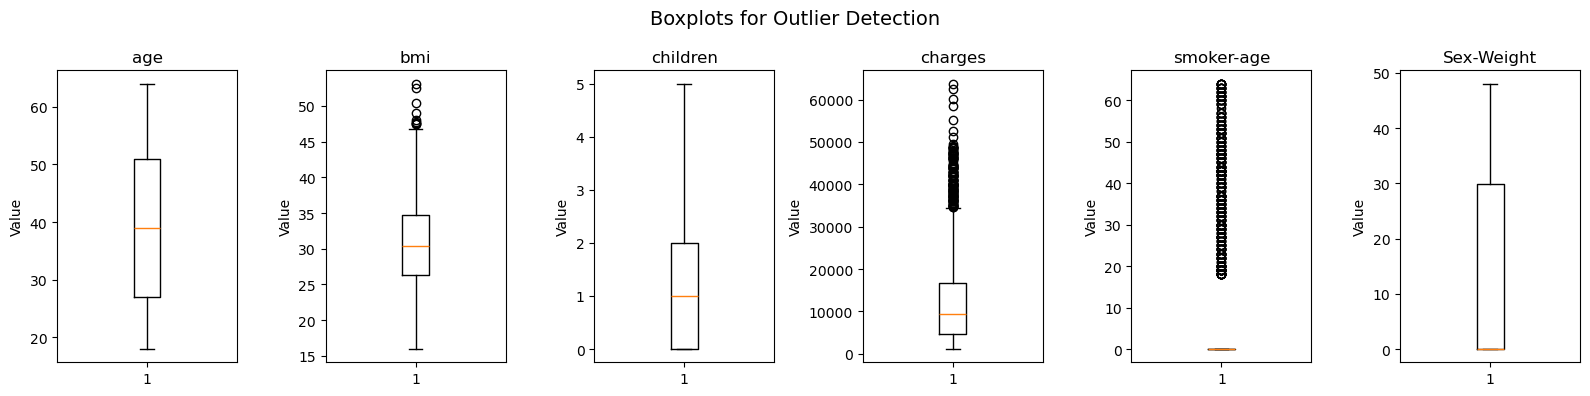

outlier counts:
  age: 0 outliers (bounds: [-9.00, 87.00])
  bmi: 9 outliers (bounds: [13.70, 47.29])
  children: 0 outliers (bounds: [-3.00, 5.00])
  charges: 139 outliers (bounds: [-13109.15, 34489.35])
  smoker-age: 274 outliers (bounds: [0.00, 0.00])
  Sex-Weight: 0 outliers (bounds: [-44.89, 74.81])


In [7]:
numeric_cols = ['age', 'bmi', 'children', 'charges', 'smoker-age', 'Sex-Weight']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
fig.suptitle('Boxplots for Outlier Detection', fontsize=14)

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df_clean[col], vert=True)
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

# outlier counts
print('outlier counts:')
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f'  {col}: {n_out} outliers (bounds: [{lower:.2f}, {upper:.2f}])')

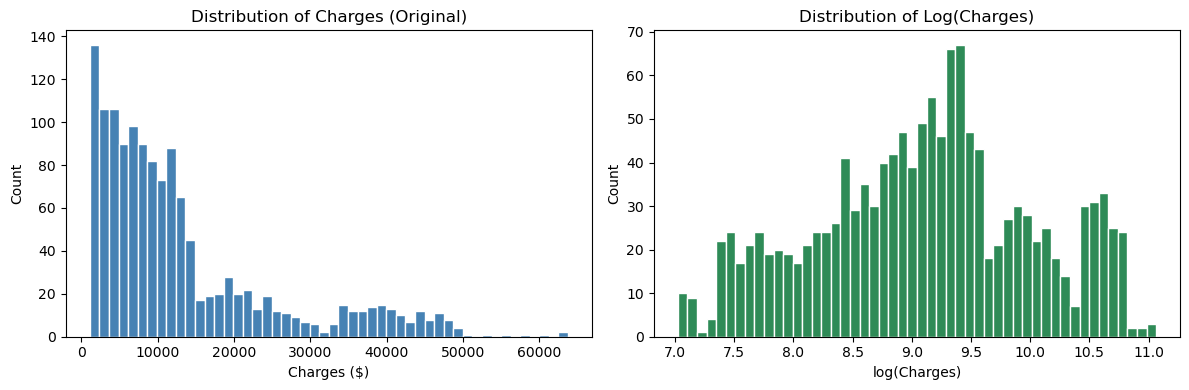

Skewness (original charges): 1.516
Skewness (log charges): -0.09


In [8]:
df_clean['log_charges'] = np.log1p(df_clean['charges'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Charges (Original)')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Count')

axes[1].hist(df_clean['log_charges'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution of Log(Charges)')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Skewness (original charges):', round(df_clean['charges'].skew(), 3))
print('Skewness (log charges):',      round(df_clean['log_charges'].skew(), 3))

In [9]:
print(f'Final cleaned dataset shape: {df_clean.shape}')
print(f'No. of features (excl. targets): {df_clean.shape[1] - 2}')
print('\nColumn list:')
print(df_clean.columns.tolist())
#df_clean.to_csv('insurance_cleaned.csv', index=False)

Final cleaned dataset shape: (1338, 17)
No. of features (excl. targets): 15

Column list:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'smoker-age', 'Sex-Weight', 'sexBool', 'smokerBool', 'regionSouthWest', 'regionSouthEast', 'regionNorthWest', 'log_charges', 'region_northwest', 'region_southeast', 'region_southwest']


model

In [10]:



feature_cols = ['age', 'bmi', 'children', 'sexBool', 'smokerBool', 'Sex-Weight', 'smoker-age', 'regionSouthWest', 'regionSouthEast', 'regionNorthWest']
X = df[feature_cols].values
y_log = df['log_charges'].values    # log-transformed
y_raw = df['charges'].values        # original dollar scale


X_train, X_temp, y_train, y_temp, y_raw_train, y_raw_temp = train_test_split(
    X, y_log, y_raw, test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test, y_raw_val, y_raw_test = train_test_split(
    X_temp, y_temp, y_raw_temp, test_size=0.50, random_state=42
)

print(f'Features:       {len(feature_cols)} → {feature_cols}')
print(f'Training set:   {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')

Features:       10 → ['age', 'bmi', 'children', 'sexBool', 'smokerBool', 'Sex-Weight', 'smoker-age', 'regionSouthWest', 'regionSouthEast', 'regionNorthWest']
Training set:   1070 samples
Validation set: 134 samples
Test set:       134 samples


In [11]:

nn_unscaled = MLPRegressor(hidden_layer_sizes=(256), max_iter=500, random_state=42)
nn_unscaled.fit(X_train, y_train)
r2_unscaled = r2_score(y_val, nn_unscaled.predict(X_val))

nn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPRegressor(hidden_layer_sizes=(256), max_iter=500, random_state=42))
])
nn_scaled.fit(X_train, y_train)
r2_scaled = r2_score(y_val, nn_scaled.predict(X_val))

print(f'R² WITHOUT scaling: {r2_unscaled:.4f}')
print(f'R² WITH scaling:    {r2_scaled:.4f}')

R² WITHOUT scaling: 0.7444
R² WITH scaling:    0.7933


In [18]:
architectures = {
    'Small (32)': (32,),
    'Medium (64, 32)': (64, 32),
    'Large (128, 64, 32)': (128, 64, 32),
    'Wide (256)': (256,),
    'Very Wide': (512,),
    'Micro Deep': (32,32,32,32,32),
    'Reverse Pyramid': (32,64,128),
    'Bottleneck': (128,32,128)
}

activations = {
    'ReLU': 'relu',
    'Tanh': 'tanh',
    'Logistic': 'logistic'
}

solvers = ['adam', 'lbfgs']

results = {}

print('Architecture + Activation + Solver Comparison — 5-Fold CV (R²)')
print('=' * 80)

for arch_name, layers in architectures.items():
    for act_name, act in activations.items():
        for sol in solvers:

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('nn', MLPRegressor(
                    hidden_layer_sizes=layers,
                    activation=act,
                    solver=sol,
                    max_iter=500,
                    random_state=42
                ))
            ])

            scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')

            key = f'{arch_name} + {act_name} + {sol}'
            results[key] = scores

            # Fit once to count parameters
            pipe.fit(X_train, y_train)
            nn_model = pipe.named_steps['nn']

            n_params = sum(w.size for w in nn_model.coefs_) + \
                       sum(b.size for b in nn_model.intercepts_)

            print(f'{key:<45} R² = {scores.mean():.4f} ± {scores.std():.4f} ({n_params} params)')

Architecture + Activation + Solver Comparison — 5-Fold CV (R²)
Small (32) + ReLU + adam                      R² = 0.7687 ± 0.0448 (385 params)
Small (32) + ReLU + lbfgs                     R² = 0.7797 ± 0.0409 (385 params)
Small (32) + Tanh + adam                      R² = 0.8155 ± 0.0377 (385 params)
Small (32) + Tanh + lbfgs                     R² = 0.7090 ± 0.0706 (385 params)
Small (32) + Logistic + adam                  R² = 0.7809 ± 0.0429 (385 params)
Small (32) + Logistic + lbfgs                 R² = 0.7281 ± 0.0615 (385 params)
Medium (64, 32) + ReLU + adam                 R² = 0.8026 ± 0.0311 (2817 params)
Medium (64, 32) + ReLU + lbfgs                R² = 0.6386 ± 0.0694 (2817 params)
Medium (64, 32) + Tanh + adam                 R² = 0.8144 ± 0.0343 (2817 params)
Medium (64, 32) + Tanh + lbfgs                R² = 0.4497 ± 0.1701 (2817 params)
Medium (64, 32) + Logistic + adam             R² = 0.7910 ± 0.0319 (2817 params)
Medium (64, 32) + Logistic + lbfgs            R² = 0

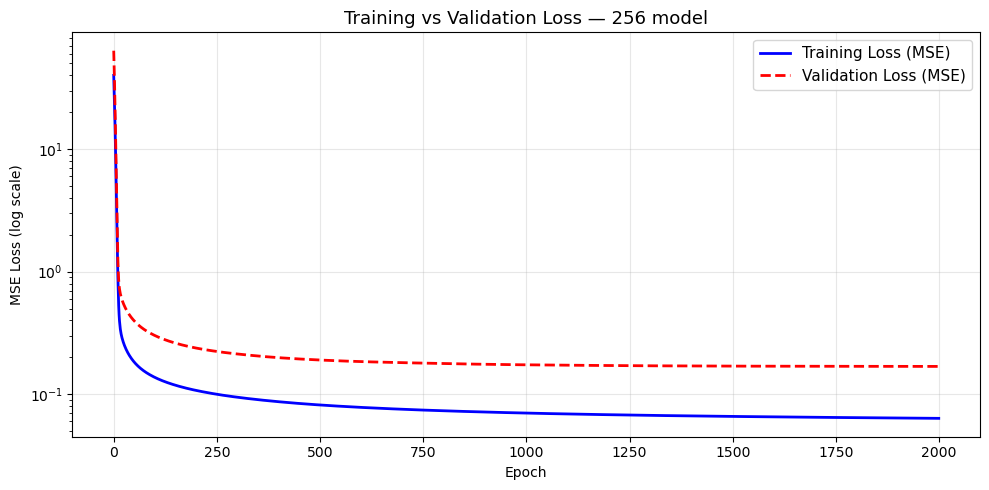

Final training loss:   0.0635
Final validation loss: 0.1685


In [19]:
scaler_check = StandardScaler()
X_train_sc = scaler_check.fit_transform(X_train)
X_val_sc   = scaler_check.transform(X_val)

nn_track = MLPRegressor(
    hidden_layer_sizes=(256),
    activation='relu',
    solver='sgd',
    max_iter=1,
    warm_start=True,
    random_state=42
)

train_losses, val_losses = [], []
n_epochs = 2000

for epoch in range(n_epochs):
    nn_track.fit(X_train_sc, y_train)
    train_losses.append(nn_track.loss_)
    val_pred = nn_track.predict(X_val_sc)
    val_losses.append(mean_squared_error(y_val, val_pred))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Training Loss (MSE)', color='blue', linewidth=2)
ax.plot(val_losses,   label='Validation Loss (MSE)', color='red', linewidth=2, linestyle='--')
ax.set_title(f'Training vs Validation Loss — {256} model', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (log scale)')
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final training loss:   {train_losses[-1]:.4f}')
print(f'Final validation loss: {val_losses[-1]:.4f}')

In [21]:
param_grid = {
    'nn__hidden_layer_sizes': [
        (32,),
        (64, 32),
        (128, 64, 32),
        (256,),
        (512,),
        (32,32,32,32,32),
        (32,64,128),
        (128,32,128)
    ],
    
    'nn__activation': ['relu', 'tanh', 'logistic'],
    
    'nn__solver': ['adam', 'lbfgs'],
    
    'nn__learning_rate': ['constant', 'adaptive'],
    
    'nn__learning_rate_init': [0.0005, 0.001]
}
grid = GridSearchCV(
    nn_scaled,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_nn = grid.best_estimator_

y_pred_log = best_nn.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)   # convet back from log scale

r2_log   = r2_score(y_test, y_pred_log)
mae_log  = mean_absolute_error(y_test, y_pred_log)

r2_raw   = r2_score(y_raw_test, y_pred_raw)
mae_raw  = mean_absolute_error(y_raw_test, y_pred_raw)

print(best_nn.named_steps['nn'].get_params())
print(f'Log-scale   R²:   {r2_log:.4f}')
print(f'Log-scale   MAE:  {mae_log:.4f}')
print()
print(f'Dollar-scale R²:   {r2_raw:.4f}')
print(f'Dollar-scale MAE:  ${mae_raw:,.2f}')

Fitting 5 folds for each of 192 candidates, totalling 960 fits
{'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (32,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 500, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Log-scale   R²:   0.9041
Log-scale   MAE:  0.1981

Dollar-scale R²:   0.8615
Dollar-scale MAE:  $2,569.78


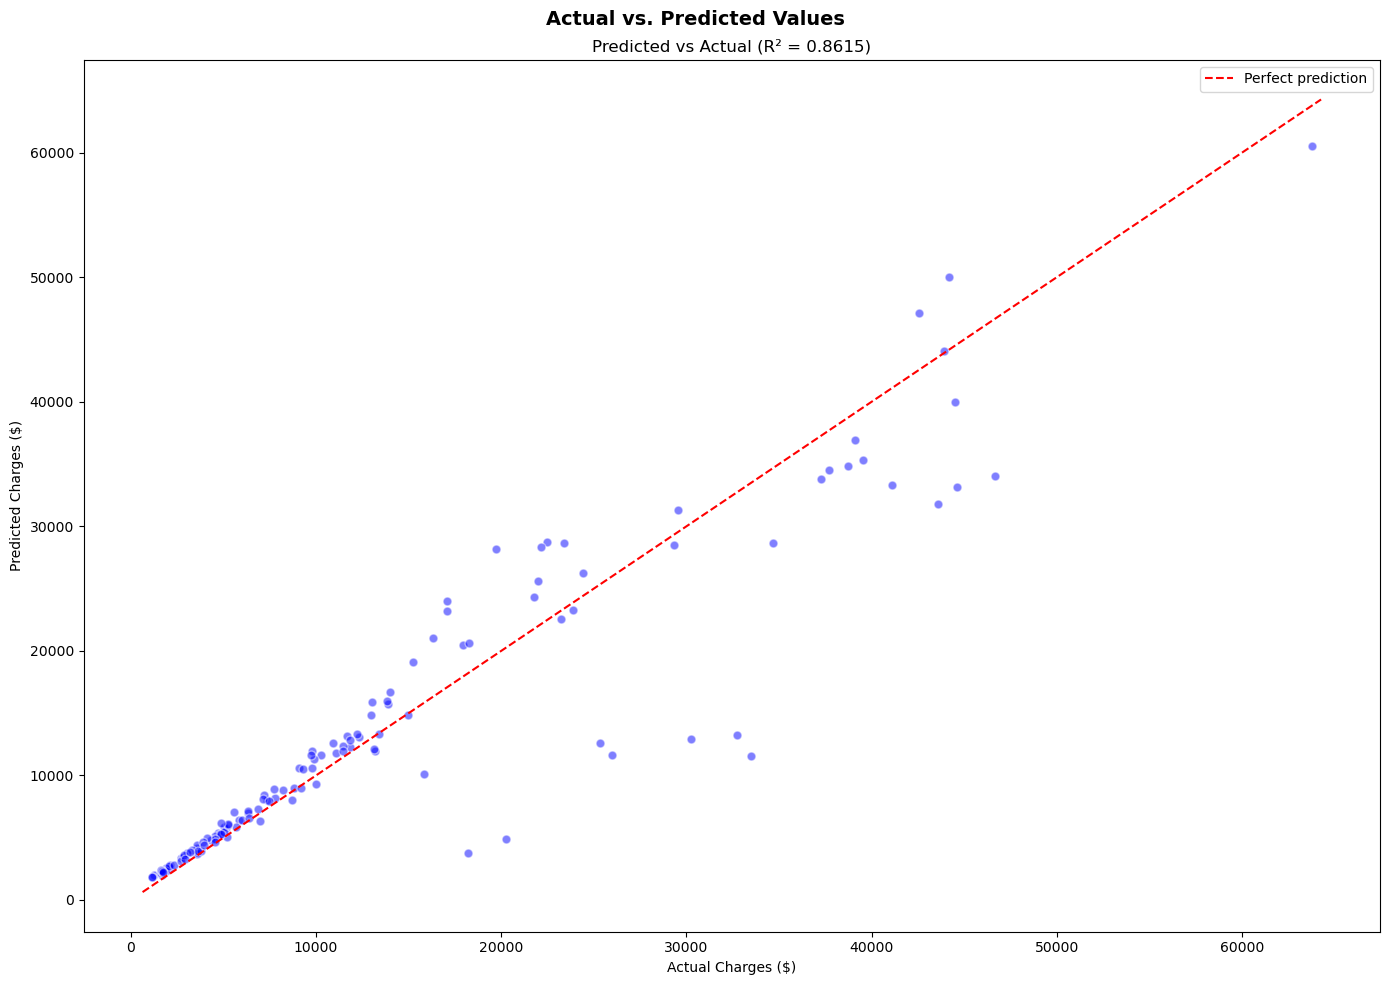

Residual mean:  $457.45
Residual std:   $4,792.11
Max error:      $21,895.84


In [22]:
residuals = y_raw_test - y_pred_raw

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
fig.suptitle('Actual vs. Predicted Values', fontsize=14, fontweight='bold')

ax.scatter(y_raw_test, y_pred_raw, alpha=0.5,
           color='blue', edgecolors='white', s=40)

lims = [min(y_raw_test.min(), y_pred_raw.min()) - 500,
        max(y_raw_test.max(), y_pred_raw.max()) + 500]

ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual Charges ($)')
ax.set_ylabel('Predicted Charges ($)')
ax.set_title(f'Predicted vs Actual (R² = {r2_raw:.4f})')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Residual mean:  ${residuals.mean():,.2f}')
print(f'Residual std:   ${residuals.std():,.2f}')
print(f'Max error:      ${np.abs(residuals).max():,.2f}')

feature importance

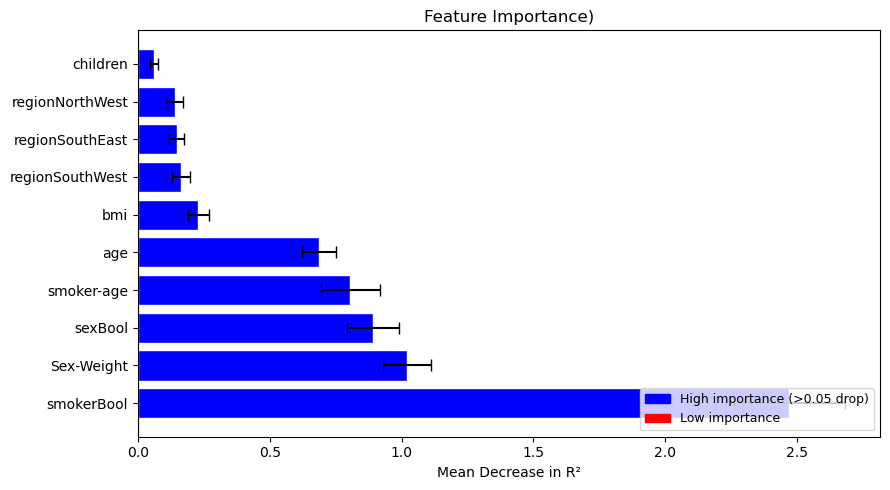


Feature Importance
---------------------------------------------
  smokerBool                +2.4698 ± 0.2105
  Sex-Weight                +1.0217 ± 0.0907
  sexBool                   +0.8926 ± 0.0985
  smoker-age                +0.8059 ± 0.1128
  age                       +0.6861 ± 0.0648
  bmi                       +0.2292 ± 0.0396
  regionSouthWest           +0.1631 ± 0.0355
  regionSouthEast           +0.1473 ± 0.0284
  regionNorthWest           +0.1407 ± 0.0311
  children                  +0.0615 ± 0.0154


In [24]:
perm_result = permutation_importance(
    best_nn, X_test, y_test,
    n_repeats=30, random_state=42, scoring='r2'
)

sorted_idx = perm_result.importances_mean.argsort()[::-1]
sorted_names  = np.array(feature_cols)[sorted_idx]
sorted_means  = perm_result.importances_mean[sorted_idx]
sorted_stds   = perm_result.importances_std[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = ['blue' if m > 0.05 else 'red' for m in sorted_means]
ax.barh(sorted_names, sorted_means, xerr=sorted_stds,
        color=colors_fi, edgecolor='white', capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Feature Importance)',
             fontsize=12)
ax.set_xlabel('Mean Decrease in R²')

red_patch  = mpatches.Patch(color='blue', label='High importance (>0.05 drop)')
blue_patch = mpatches.Patch(color='red', label='Low importance')
ax.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nFeature Importance')
print('-' * 45)
for name, mean, std in zip(sorted_names, sorted_means, sorted_stds):
    print(f'  {name:<25} {mean:+.4f} ± {std:.4f}')

Bootstrap 95% Confidence Intervals:
  R²:   [0.7294,  0.9034]   point estimate: 0.8285
  MAE:  [$2,021.67,  $3,563.46]   point estimate: $2,766.59


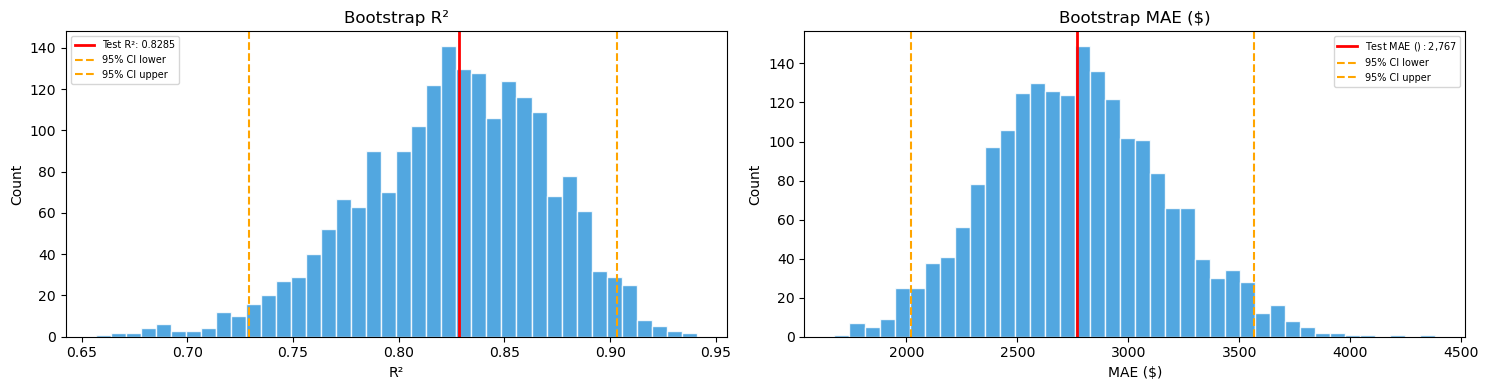

In [25]:
np.random.seed(42)
n_bootstrap = 2000
boot_r2, boot_mae = [], []

for _ in range(n_bootstrap):
    idx = np.random.choice(len(y_raw_test), size=len(y_raw_test), replace=True)
    boot_r2.append(r2_score(y_raw_test[idx], y_pred_raw[idx]))
    boot_mae.append(mean_absolute_error(y_raw_test[idx], y_pred_raw[idx]))

ci = {}
for name, data, point in [('R²', boot_r2, r2_raw),
                            ('MAE',  boot_mae,  mae_raw)]:
    lo, hi = np.percentile(data, [2.5, 97.5])
    ci[name] = (lo, hi, point)
print('Bootstrap 95% Confidence Intervals:')
print(f"  R²:   [{ci['R²'][0]:.4f},  {ci['R²'][1]:.4f}]   point estimate: {ci['R²'][2]:.4f}")
print(f"  MAE:  [${ci['MAE'][0]:,.2f},  ${ci['MAE'][1]:,.2f}]   point estimate: ${ci['MAE'][2]:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, (metric, data, point) in zip(axes, [
    ('R²', boot_r2, r2_raw),
    ('MAE ($)',  boot_mae,  mae_raw)
]):
    lo, hi = np.percentile(data, [2.5, 97.5])
    ax.hist(data, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    ax.axvline(point, color='red',    linestyle='-',  linewidth=2,   label=f'Test {metric}: {point:.4f}' if metric == 'R²' else f'Test {metric}: ${point:,.0f}')
    ax.axvline(lo,    color='orange', linestyle='--', linewidth=1.5, label=f'95% CI lower')
    ax.axvline(hi,    color='orange', linestyle='--', linewidth=1.5, label=f'95% CI upper')
    ax.set_title(f'Bootstrap {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

cross vaildation

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2   = cross_val_score(best_nn, X, y_log, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(best_nn, X, y_log, cv=kf,
                                    scoring='neg_mean_squared_error'))
cv_mae  = -cross_val_score(best_nn, X, y_log, cv=kf,
                            scoring='neg_mean_absolute_error')

print('\n5-Fold Cross-Validation Results — Neural Network')
print('=' * 52)
print(f"{'Fold':<8} {'R²':>8} {'MAE':>10}")
print('-' * 42)
for i, (r2, mae) in enumerate(zip(cv_r2, cv_mae), 1):
    print(f"Fold {i:<4} {r2:>8.4f} {mae:>10.4f}")
print('-' * 42)
print(f"{'Mean':<8} {cv_r2.mean():>8.4f} {cv_rmse.mean():>10.4f} {cv_mae.mean():>10.4f}")
print(f"{'Std':<8} {cv_r2.std():>8.4f} {cv_rmse.std():>10.4f} {cv_mae.std():>10.4f}")


5-Fold Cross-Validation Results — Neural Network
Fold           R²        MAE
------------------------------------------
Fold 1      0.8477     0.2041
Fold 2      0.8043     0.2315
Fold 3      0.8338     0.2081
Fold 4      0.7835     0.2368
Fold 5      0.8212     0.2247
------------------------------------------
Mean       0.8181     0.3901     0.2210
Std        0.0224     0.0157     0.0129
